In [1]:
import pandas as pd
import os
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import spearmanr, pearsonr
import numpy as np
from sklearn.preprocessing import OneHotEncoder
from sklearn.preprocessing import StandardScaler
import lib

# Toujours afficher tous le contenu du Dataframe
pd.set_option('display.max_columns', None)

# Pré-requis : exécuter 1-analyse_exploratoire pour obtenir le fichier unifié et nettoyé
file_path = './assets/sirh_unifie.csv'
df = None

if os.path.exists(file_path):
    df = pd.read_csv(file_path)
else:
    print(f"✗ Le fichier {file_path} n'existe pas")
    print("Assurez-vous d'avoir bien exécuté la partie 1-analyse_exploratoire")


# Préparer la modélisation
## Définition de la cible

Dans notre cas la variable cible pour comprendre l'attrition est claire, il s'agit de `a_quitte_l_entreprise`

## Préparation des données

### Normalisation des valeurs binaires


In [2]:
# Normalisation des champs booléens (True/False vers 1/0)
colonnes_bool = ['heure_supplementaires', 'a_quitte_l_entreprise']
for col in colonnes_bool:
    df[col] = df[col].apply(lambda x: 1 if x == 'Oui' else 0)

# Conversion de la colonne "genre" en entiers
df['genre'] = df['genre'].apply(lambda x: 0 if x == 'M' else 1)  


### Normalisation des pourcentages

In [3]:
def normalize_average(x):
    return float(x.replace('%', '')) / 100
    
df['augementation_salaire_precedente'] = df['augementation_salaire_precedente'].apply(normalize_average) 

### Normalisation des notes d'évaluation

In [4]:
# Fonction de normalisation pour les notes (1-4 vers 0-1)
def normalize_note(x):
    return (x - 1) / (4 - 1)

# Colonnes de notes à normaliser
colonnes_notes = [
    'satisfaction_employee_environnement',
    'note_evaluation_precedente',
    'satisfaction_employee_nature_travail',
    'satisfaction_employee_equipe',
    'satisfaction_employee_equilibre_pro_perso',
    'note_evaluation_actuelle'
]

# Application de la normalisation
for col in colonnes_notes:
    df[col] = df[col].apply(normalize_note)

### Encodage des valeurs catégorielles

#### Catégories non ordinales
Pour les catégories qui ne représentent pas une notion d'ordre de classement (par exemple valeurs A > B > C, etc.), nous utilisons un `OneHotEncoder`


In [5]:
# Initialiser le OneHotEncoder avec drop='first' pour n-1 catégories
encoder = OneHotEncoder(drop='first', sparse_output=False, dtype=int)

# Colonnes catégorielles non ordinales
categories_non_ordinales = ['statut_marital', 'departement', 'poste', 'domaine_etude']

# Encoder la colonne statut_marital
encoded_data = encoder.fit_transform(df[categories_non_ordinales])

# Récupérer les noms des nouvelles colonnes
feature_names = encoder.get_feature_names_out(categories_non_ordinales)

# Créer un DataFrame avec les données encodées
df_encoded = pd.DataFrame(encoded_data, columns=feature_names, index=df.index)

# Supprimer les anciennes colonnes et ajouter les nouvelles
df = df.drop(categories_non_ordinales, axis=1)
df = pd.concat([df, df_encoded], axis=1)

# Vérification
print("Nouvelles colonnes créées :")
for name in feature_names:
    print(f"  - {name}")

print(f"\nNombre de nouvelles colonnes : {len(feature_names)}")
print(f"Type de données : {df_encoded.dtypes.iloc[0]}")

Nouvelles colonnes créées :
  - statut_marital_Divorcé(e)
  - statut_marital_Marié(e)
  - departement_Consulting
  - departement_Ressources Humaines
  - poste_Cadre Commercial
  - poste_Consultant
  - poste_Directeur Technique
  - poste_Manager
  - poste_Représentant Commercial
  - poste_Ressources Humaines
  - poste_Senior Manager
  - poste_Tech Lead
  - domaine_etude_Entrepreunariat
  - domaine_etude_Infra & Cloud
  - domaine_etude_Marketing
  - domaine_etude_Ressources Humaines
  - domaine_etude_Transformation Digitale

Nombre de nouvelles colonnes : 17
Type de données : int64


#### Catégories ordinales
On a une catégorie ordinale dans notre jeu de données : `frequence_deplacements`. Les valeurs sont croissantes.
On va transformer cette catégorie pour la rendre lisible pour nos modèles.

In [6]:
frequence_mapping = {
    'Aucun': 0,
    'Occasionnel': 1, 
    'Frequent': 2
}

# Appliquer l'encodage
df['frequence_deplacement_encoded'] = df['frequence_deplacement'].map(frequence_mapping)

# Vérifier le résultat
print("\nVérification de l'encodage:")
print(df[['frequence_deplacement', 'frequence_deplacement_encoded']].value_counts().sort_index())

df = df.drop(['frequence_deplacement'], axis=1)


Vérification de l'encodage:
frequence_deplacement  frequence_deplacement_encoded
Aucun                  0                                 150
Frequent               2                                 277
Occasionnel            1                                1043
Name: count, dtype: int64


### Diminution des valeurs de grande amplitude
Certaines valeurs ont une grande amplitude en comparaison aux autres. C'est le cas du `revenu_mensuel` notamment.
Nous devons diminuer l'amplitude pour que la régression fonctionne correctement.

In [7]:
scaler = StandardScaler()
df["revenu_mensuel"] = scaler.fit_transform(df[["revenu_mensuel"]])

## Analyse des corrélations
### Correlations linéaires

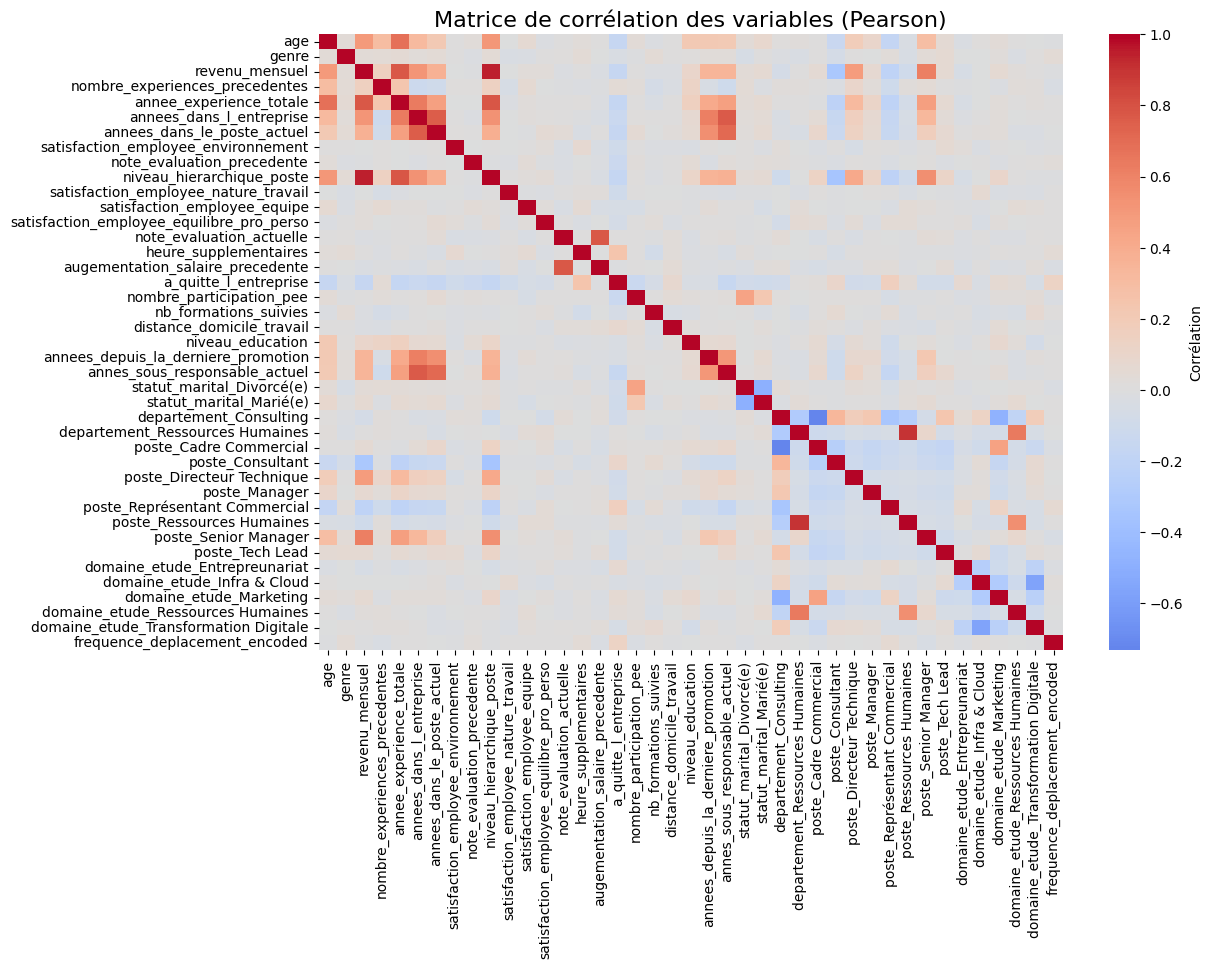


Variables analysées: 23
['age', 'genre', 'revenu_mensuel', 'nombre_experiences_precedentes', 'annee_experience_totale', 'annees_dans_l_entreprise', 'annees_dans_le_poste_actuel', 'satisfaction_employee_environnement', 'note_evaluation_precedente', 'niveau_hierarchique_poste', 'satisfaction_employee_nature_travail', 'satisfaction_employee_equipe', 'satisfaction_employee_equilibre_pro_perso', 'note_evaluation_actuelle', 'heure_supplementaires', 'augementation_salaire_precedente', 'nombre_participation_pee', 'nb_formations_suivies', 'distance_domicile_travail', 'niveau_education', 'annees_depuis_la_derniere_promotion', 'annes_sous_responsable_actuel', 'frequence_deplacement_encoded']

=== CORRÉLATIONS DE PEARSON AVEC LE DÉPART DE L'ENTREPRISE ===
(Triées par corrélation absolue décroissante)
--------------------------------------------------------------------------------
heure_supplementaires                    | r =  0.2461 | p =  0.0000 ***
annee_experience_totale                  | r 

In [8]:
lib.display_pearson_matrix(df, "Matrice de corrélation des variables (Pearson)", annot=False)    

# Calculer les corrélations de Pearson avec la variable cible
target_var = 'a_quitte_l_entreprise'

# Sélectionner uniquement les variables numériques (exclure les variables catégorielles encodées en one-hot)
numeric_vars = [col for col in df.columns if col != target_var and not col.startswith(('statut_marital_', 'departement_', 'poste_', 'domaine_etude_'))]

lib.display_pearson_correlation(df, target_var, numeric_vars)


#### Corrélations linéaires liées avec le départ de l'entreprise (cible)

Les variables suivantes montrent une corrélation (faible à modérée) avec le fait qu'un employé quitte l'entreprise :

* `heure_supplementaires` : 0.25 (plus le salarié a fait des heures supplémentaires, plus il est susceptible de quitter l'entreprise)
* `annee_experience_totale` : -0.17 (plus un salarié a d’expérience professionnelle globale, moins il a tendance à quitter l’entreprise)
* `revenu_mensuel` : -0.16 (les employés mieux rémunérés partent moins)
* `age`: -0.16 (les plus jeunes quittent significativement plus que les plus âgés)
* **Fréquence des déplacements** : -0.13 (les voyages fréquents sont modestement mais significativement associés à un plus fort taux de départ)
* **Satisfaction** en général : ~-0.075 (l'insatisfaction compte dans les facteurs de départ mais ce n'est pas le facteur premier)
  

#### Corrélations linéaires entre variables (non-cible)

On retient des corrélations linéaires fortes entre variables non-cible : 

* `revenu_mensuel` ↔ `niveau_hierarchique_poste` (r = 0.95)
* `revenu_mensuel` ↔ `annee_experience_totale` (r = 0.77)
* `annee_experience_totale` ↔ `niveau_hierarchique_poste` (r = 0.78)
* `annees_dans_l_entreprise` ↔ `annes_sous_responsable_actuel` (r = 0.77)
* `annees_dans_l_entreprise` ↔ `annees_dans_le_poste_actuel` (r = 0.76)
* `annees_dans_le_poste_actuel` ↔ `annes_sous_responsable_actuel` (r = 0.71)
* `note_evaluation_actuelle` ↔ `augmentation_salaire_precedente` (r = 0.77)
* `age` ↔ annee_experience_totale` (r = 0.68, presque >0.7)

Pour éviter une trop grande *multicolinéarité*, on va supprimer certaines variables du jeu d'entrainement : 

* `niveau_hierarchique_poste`

**Remarque : on reviendra itérativement sur cette liste au cours de notre processus**

In [9]:
# Supprimer les colonnes
df = df.drop(columns=['niveau_hierarchique_poste']) 

### Corrélations non-linéaires (PairPlot + Spearman)

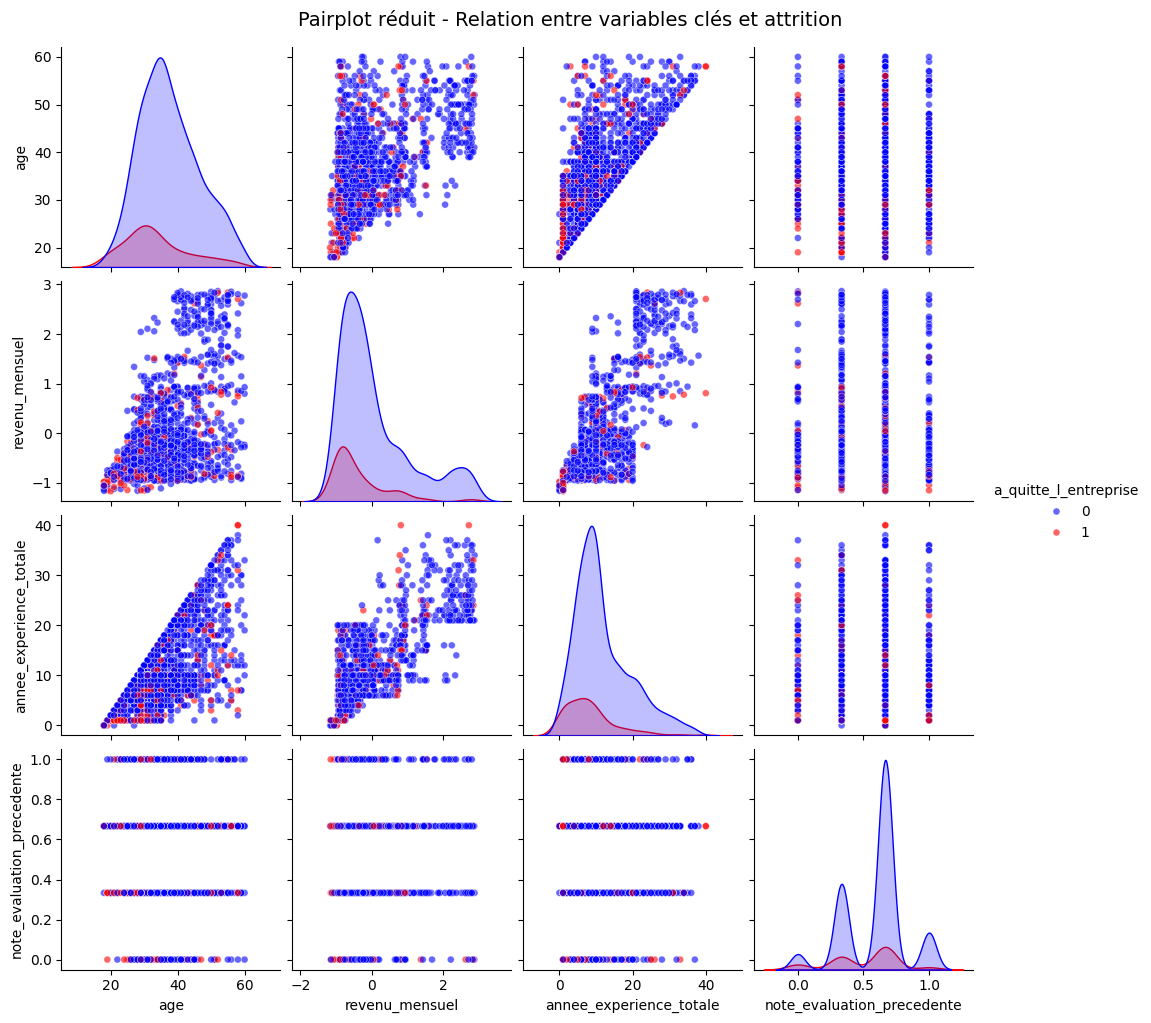

In [10]:
# Variables clés sélectionnées pour la lisibilité
key_vars_small = [
    'age', 
    'revenu_mensuel', 
    'annee_experience_totale', 
    'note_evaluation_precedente', 
    'a_quitte_l_entreprise'
]

df_small = df[key_vars_small].copy()

# Pairplot réduit et lisible
lib.display_pairplot(df_small, "a_quitte_l_entreprise", "Pairplot réduit - Relation entre variables clés et attrition")

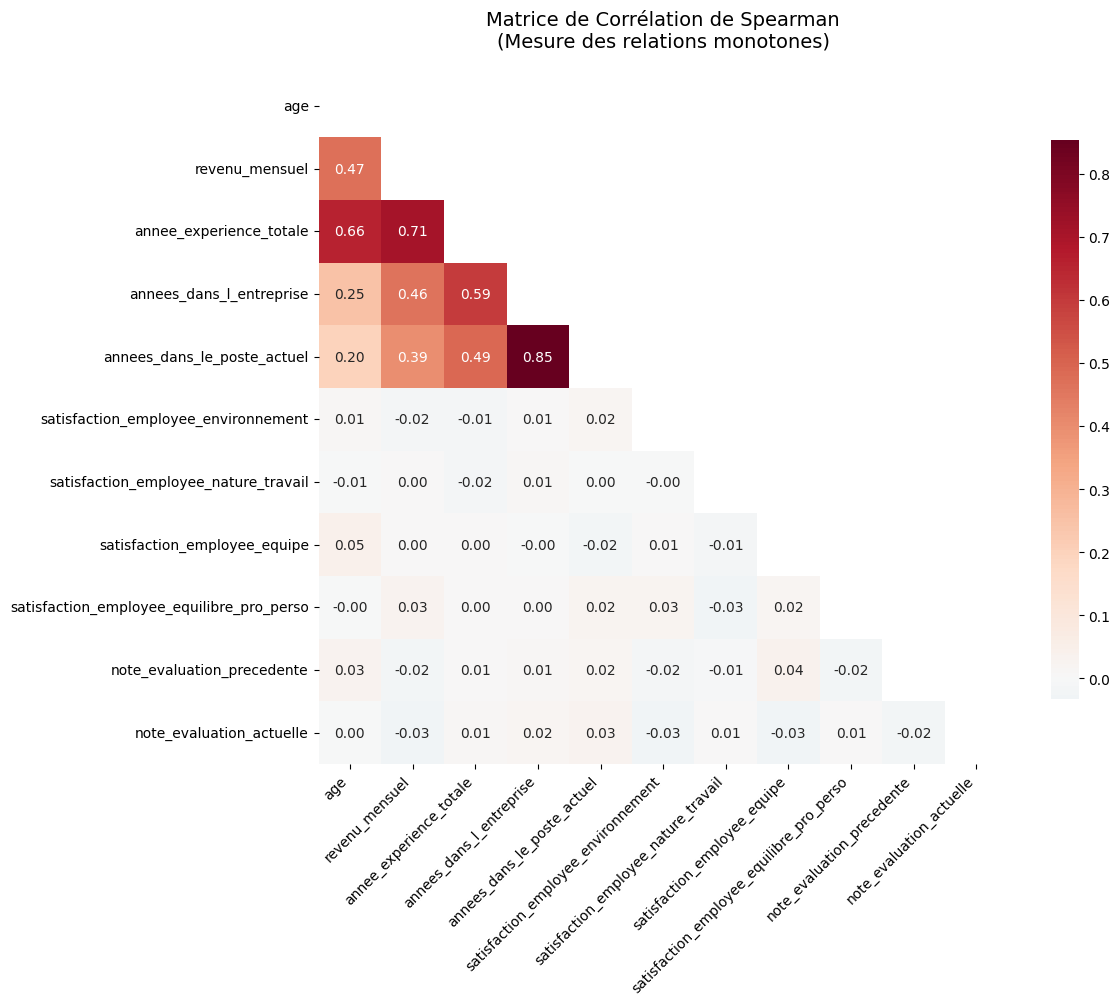

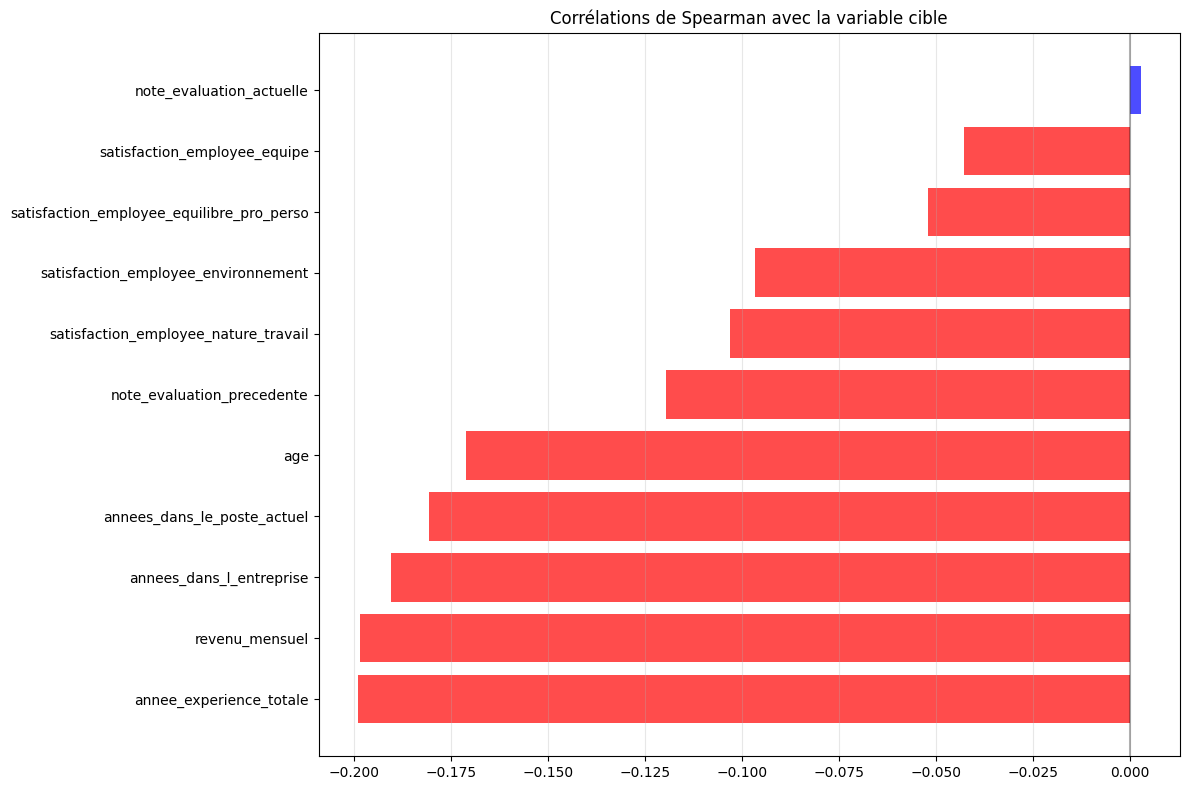

In [11]:
# Sélectionner les variables les plus pertinentes pour faire une corrélation avec la matrice de Spearman
key_vars = [
    'age', 'revenu_mensuel', 'annee_experience_totale', 
    'annees_dans_l_entreprise', 'annees_dans_le_poste_actuel',
    'satisfaction_employee_environnement', 'satisfaction_employee_nature_travail',
    'satisfaction_employee_equipe', 'satisfaction_employee_equilibre_pro_perso',
    'note_evaluation_precedente', 'note_evaluation_actuelle',
    'a_quitte_l_entreprise'
]

target_var = 'a_quitte_l_entreprise'

df_subset = df[key_vars].copy()
lib.display_spearman_matrix(df_subset, target_var)



#### Corrélations Fortes Entre Variables
**Corrélations très fortes (r > 0.8) :**

* `annees_dans_l_entreprise` ↔ `annees_dans_le_poste_actuel` (0.854) : c'est cohérent, plus on reste dans l'entreprise, plus on reste dans le même poste
  
**Corrélations fortes (0.5 < r < 0.8) :**

* `revenu_mensuel` ↔ `annee_experience_totale` (0.710) : L'expérience augmente le salaire
* `age ↔ annee_experience_totale` (0.657) : L'âge est lié à l'expérience
* `annee_experience_totale` ↔ `annees_dans_l_entreprise` (0.594) : Les expérimentés restent plus longtemps
  
#### Observations sur la Satisfaction
Faibles corrélations des variables de satisfaction :

* Les variables de satisfaction montrent des corrélations faibles avec le départ (-0.052 à -0.103)
* La satisfaction n'est pas un prédicteur fort du départ dans ce dataset
* Les notes d'évaluation ont également peu d'impact sur la décision de partir

### Conclusions Clés
* Facteurs de rétention principaux : Expérience, salaire, ancienneté et âge sont les meilleurs prédicteurs de rétention
* Profil à risque : Jeunes employés, moins expérimentés, avec des salaires plus bas et peu d'ancienneté
* Satisfaction limitée : Contrairement aux attentes, la satisfaction au travail n'est pas un facteur déterminant du départ
* Multicolinéarité : Forte corrélation entre âge, expérience, salaire et ancienneté - ces variables sont interdépendantes
  
**Recommandation : A ce stade de l'analyse, se concentrer sur la politique salariale et la gestion de carrière plutôt que sur les seuls aspects de satisfaction pour réduire le turnover.**

In [12]:
# Sauvegarder le fichier normalisé
output_file = './assets/sirh_normalized.csv'
df.to_csv(output_file, index=False)

## Feature Engineering
# Todo: compléter, revoir